# Ctrl + M + L to show line number

### Import libraries and load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 20)
sns.set(font_scale=1.15)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('Credit-Scoring/credit_scoring_dataset/credit_scoring_dataset.csv', index_col='customer_id')

print(df.shape)
df.head()

(32581, 11)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,cb_person_default_on_file,cb_person_cred_hist_length
customer_id,,,,,,,,,,,
616d39c7-4cca-4e2e-a65c-848a9543cfe1,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,Y,3
49d00b80-f7ec-41ec-8063-8cc32f384268,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,N,2
25172c7f-160a-44ac-b271-5833b7a679f6,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,N,3
a8f721ac-9696-48b3-ae35-bc8b13592d26,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,N,2
53be6c0c-0a33-41c1-a8d0-e9784b077f98,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,Y,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 32581 entries, 616d39c7-4cca-4e2e-a65c-848a9543cfe1 to 5185b116-af1e-4951-b9f0-d9d1f0d79b3e
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   cb_person_default_on_file   32581 non-null  str    
 10  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 3.0+ MB


### Univariate analysis

loan_status
Good    25472
Bad      7109
Name: count, dtype: int64
****************************************
loan_status
Good    78.180535
Bad     21.819465
Name: count, dtype: float64
****************************************


C:\Users\User\AppData\Local\Temp\ipykernel_920\4159510509.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status',data=df_target, palette='tab10')


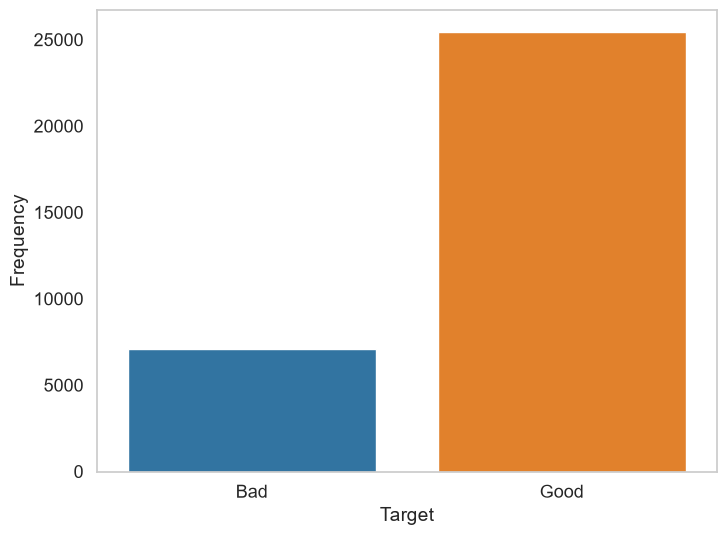

Imbalance Ratio (IR) = 1:3


In [4]:
df_target = df[['loan_status']]
df_target['loan_status'] = np.where(df_target['loan_status']==1,'Bad','Good')

print(df_target['loan_status'].value_counts())
print('*'*40)
print(df_target['loan_status'].value_counts()/len(df_target)*100)
print('*'*40)

fig = plt.figure(figsize=(8,6))
sns.countplot(x='loan_status',data=df_target, palette='tab10')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.grid(False)
plt.show();

## IR = (negative_class/positive_class)
## Where positive_class is the number of minority class samples and negative_class is the number of majority class samples

count_good = len(df_target.loc[df_target['loan_status']=='Good'])
count_bad = len(df_target.loc[df_target['loan_status']=='Bad'])

print("Imbalance Ratio (IR) = 1:{}".format(int(count_good/count_bad)))

In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218195,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413027,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,30.000000


C:\Users\User\AppData\Local\Temp\ipykernel_920\3942537703.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['person_age'], kde=False)


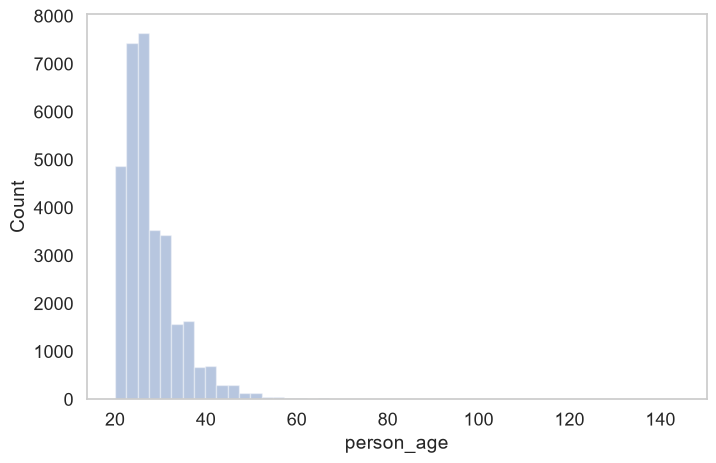

In [6]:
plt.subplots(figsize=(8,5))
sns.distplot(df['person_age'], kde=False)
plt.grid(False)
plt.ylabel('Count')
plt.show();

C:\Users\User\AppData\Local\Temp\ipykernel_920\571683575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['person_income'], kde=False)


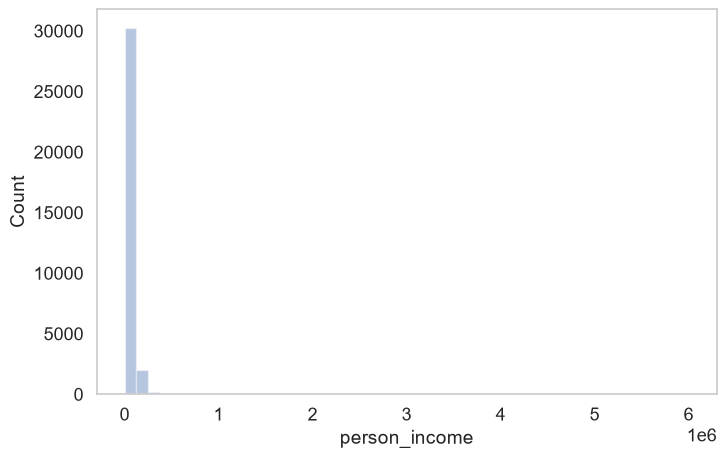

In [7]:
plt.subplots(figsize=(8,5))
sns.distplot(df['person_income'], kde=False)
plt.grid(False)
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_920\2253602431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="person_home_ownership", data=df,palette='tab10')


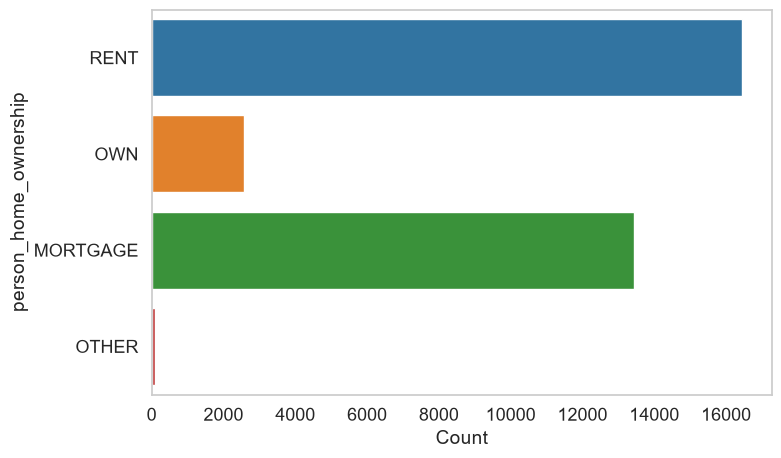

In [8]:
plt.subplots(figsize=(8,5))
sns.countplot(y="person_home_ownership", data=df,palette='tab10')
plt.grid(False)
plt.xlabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_920\1014351262.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['person_emp_length'], kde=False)


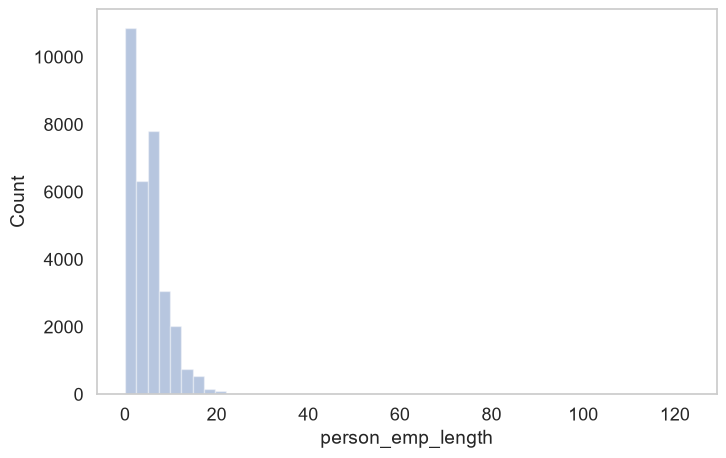

In [9]:
plt.subplots(figsize=(8,5))
sns.distplot(df['person_emp_length'], kde=False)
plt.grid(False)
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_920\2200606451.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_amnt'], kde=False)


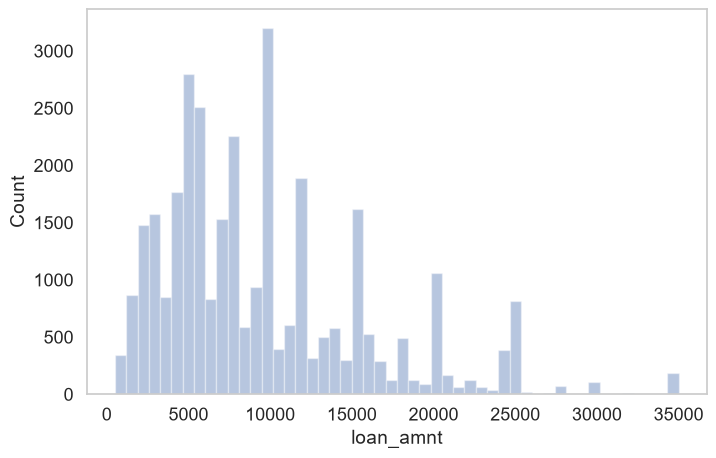

In [10]:
plt.subplots(figsize=(8,5))
sns.distplot(df['loan_amnt'], kde=False)
plt.grid(False)
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_920\3681474379.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_int_rate'], kde=False)


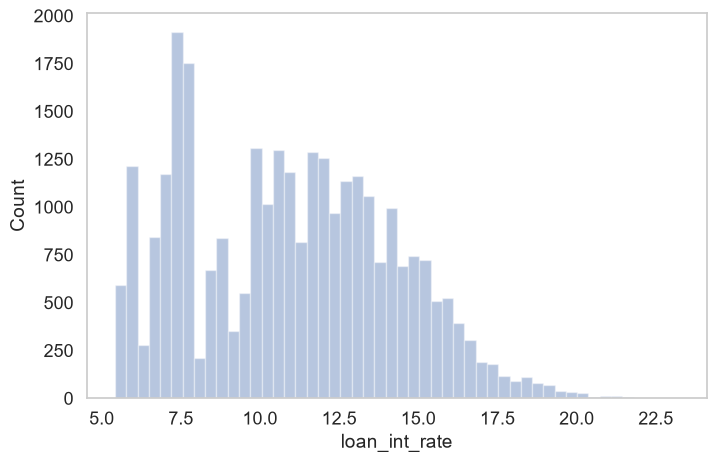

In [11]:
plt.subplots(figsize=(8,5))
sns.distplot(df['loan_int_rate'], kde=False)
plt.grid(False)
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_920\1481550394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="loan_intent", data=df,palette='tab10')


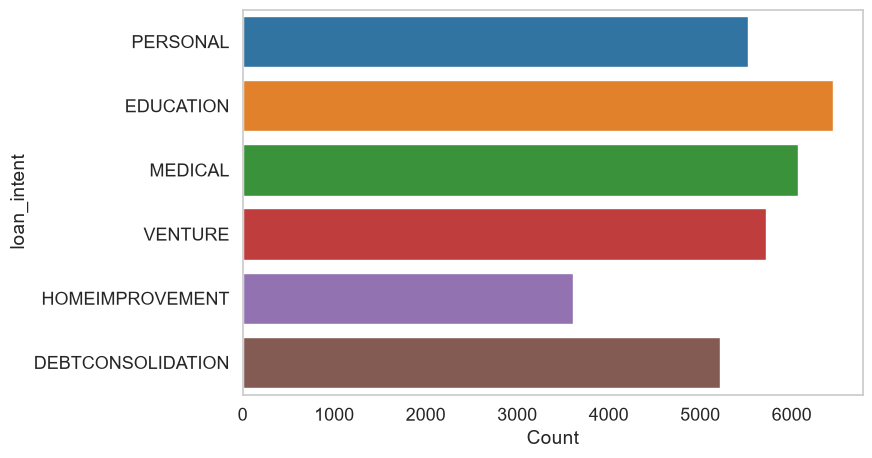

In [12]:
plt.subplots(figsize=(8,5))
sns.countplot(y="loan_intent", data=df,palette='tab10')
plt.grid(False)
plt.xlabel('Count')
plt.show()

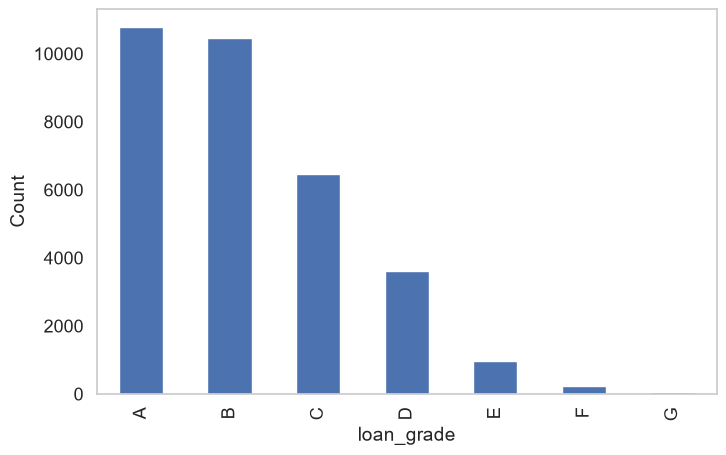

In [13]:
plt.subplots(figsize=(8,5))
df['loan_grade'].value_counts().plot(kind="bar")
plt.grid(False)
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_920\2645137793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="cb_person_default_on_file", data=df,palette='tab10')


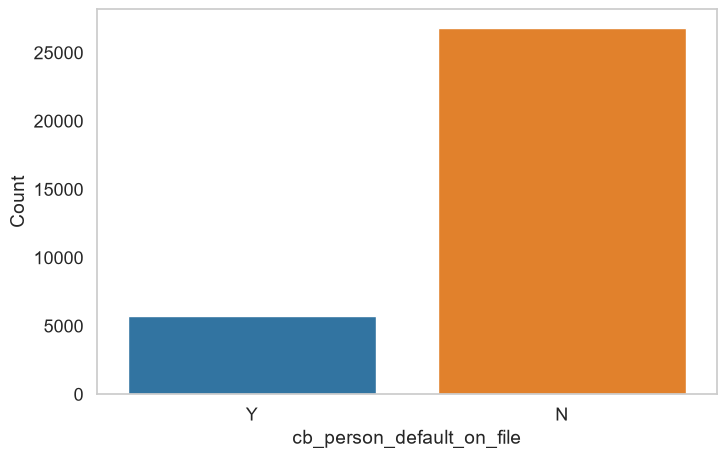

In [14]:
plt.subplots(figsize=(8,5))
sns.countplot(x="cb_person_default_on_file", data=df,palette='tab10')
plt.grid(False)
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_920\623980597.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cb_person_cred_hist_length'], kde=False)


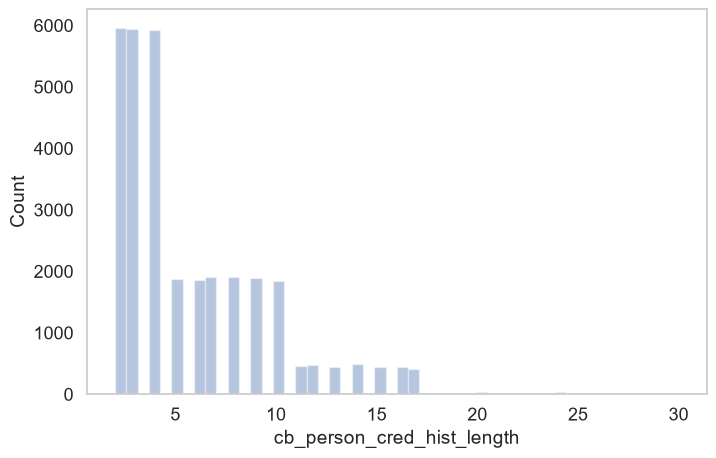

In [15]:
plt.subplots(figsize=(8,5))
sns.distplot(df['cb_person_cred_hist_length'], kde=False)
plt.grid(False)
plt.ylabel('Count')
plt.show()

### Bivariate analysis

In [16]:
df.groupby('loan_intent').agg({'loan_amnt': 'mean', 
                               'loan_int_rate': 'mean'}).sort_values(by='loan_amnt', ascending=False)

,loan_amnt,loan_int_rate
loan_intent,,
HOMEIMPROVEMENT,10360.520111,11.201152
DEBTCONSOLIDATION,9594.886800,10.983268
VENTURE,9583.777758,10.948275
PERSONAL,9573.772867,10.998221
EDUCATION,9482.678599,10.950261
MEDICAL,9259.582441,11.060194


### Exploratory Data Analysis (EDA) and Risk ranking

In [17]:
df_age = df[['loan_status', 'person_age']]
df_age['bin_person_age'] = pd.qcut(df_age['person_age'].astype(float), q=5, duplicates='drop', precision=0)
df_age = df_age.groupby('bin_person_age').agg({'loan_status': ['count', 'sum']})
df_age.columns = df_age.columns.map('_'.join)
df_age['dist'] = df_age['loan_status_count']/df_age['loan_status_count'].sum()
df_age['bad_rate'] = df_age['loan_status_sum']/df_age['loan_status_count']
df_age = df_age.reset_index()
df_age

,bin_person_age,loan_status_count,loan_status_sum,dist,bad_rate
0,"(19.0, 23.0]",8766,2092,0.269053,0.238649
1,"(23.0, 25.0]",6586,1444,0.202142,0.219253
2,"(25.0, 27.0]",4615,961,0.141647,0.208234
3,"(27.0, 32.0]",6963,1445,0.213714,0.207525
4,"(32.0, 144.0]",5651,1167,0.173445,0.206512


C:\Users\User\AppData\Local\Temp\ipykernel_920\1781557764.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['loan_status'] == 0, 'person_age'], kde=False, bins=40,
C:\Users\User\AppData\Local\Temp\ipykernel_920\1781557764.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df[

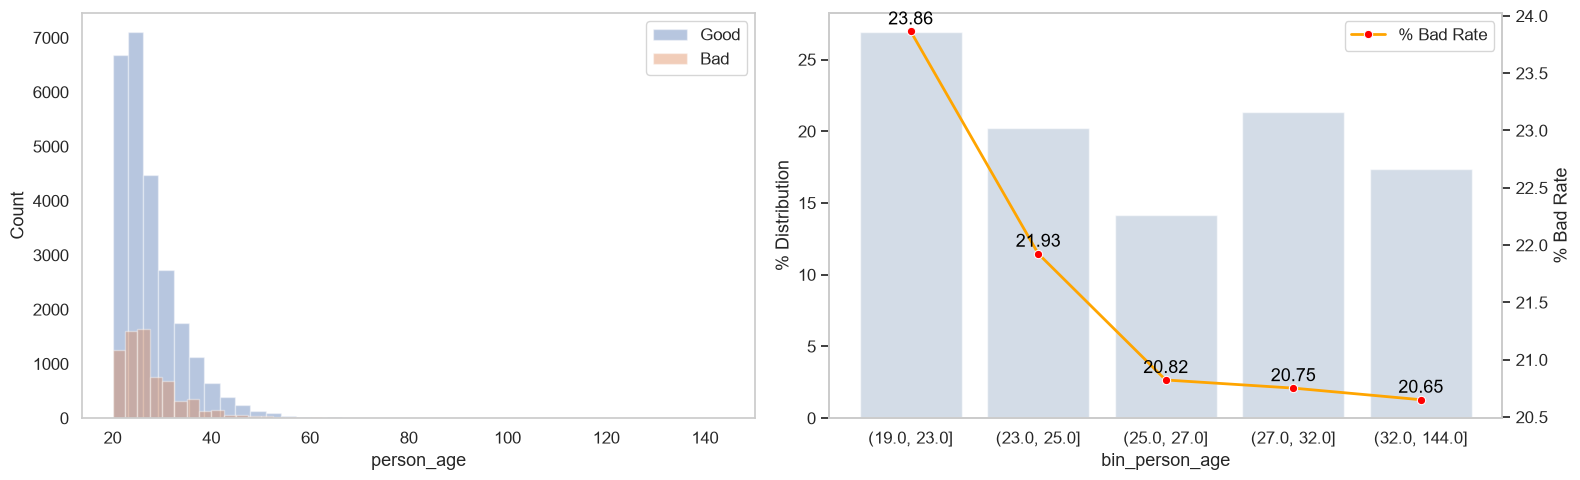

In [18]:
sns.set(font_scale=1.1)
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16,5))

### First figure is distribution plot ###

sns.distplot(df.loc[df['loan_status'] == 0, 'person_age'], kde=False, bins=40,
             label = 'Good', color = 'C0', ax = ax[0])
sns.distplot(df.loc[df['loan_status'] == 1, 'person_age'], kde=False, bins=20,
             label = 'Bad', color = 'C1', ax = ax[0])

### Second figure is bar plot + line chart ###

### y axis (left) is bar plot ###
sns.barplot(x=df_age['bin_person_age'], y=df_age['dist']*100, color='lightsteelblue', alpha=.6,
            ax = ax[1])

### y axis (right) is line chart ###
ax2 = ax[1].twinx()
ax2 = sns.lineplot(data=df_age, x=df_age.index, y=df_age['bad_rate']*100\
                   , marker='o',\
                  markerfacecolor='red', markersize=6, color='orange', 
                  linewidth=2, label='% Bad Rate')
for x,y in zip(df_age.index, df_age['bad_rate']*100):
          label = "{:.2f}".format(y)
          plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,5), ha='center', color='black') 

ax[0].legend()
ax[0].grid(False)
ax[1].grid(False)
ax2.grid(False)
ax[0].set_ylabel('Count')
ax[1].set_ylabel('% Distribution')
ax2.set_ylabel('% Bad Rate')
plt.tight_layout() 
plt.show();

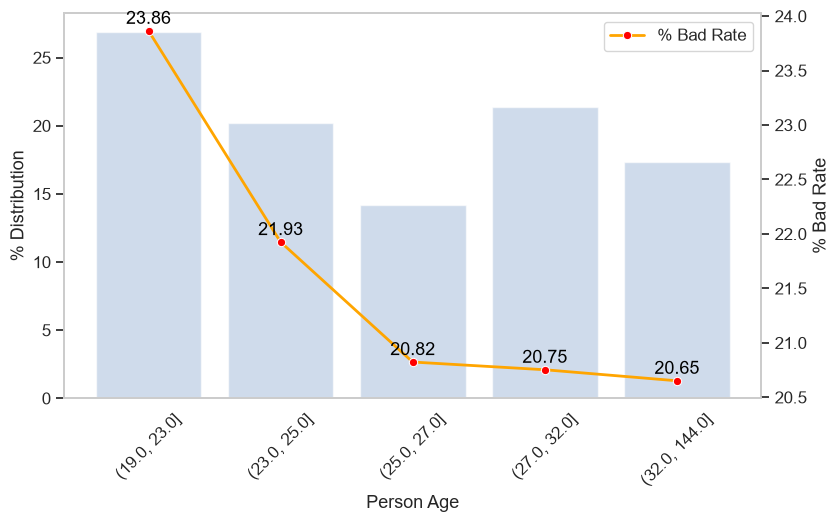

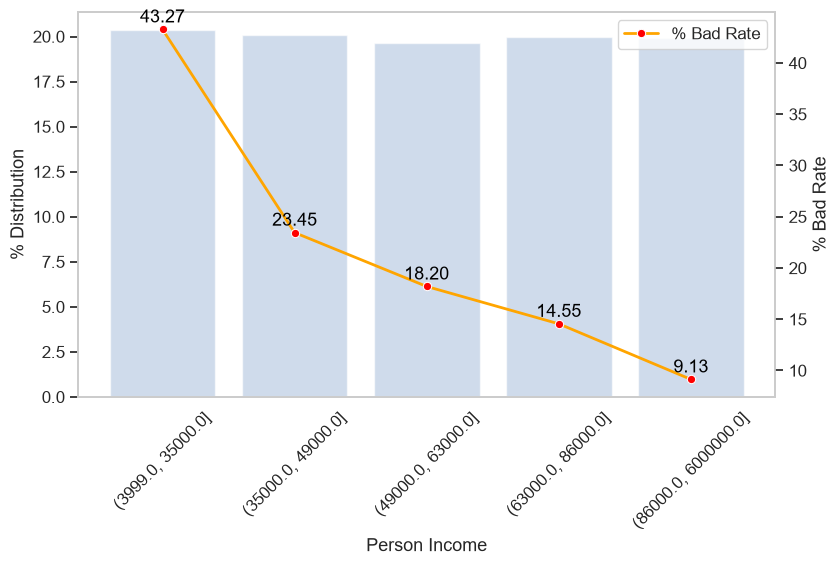

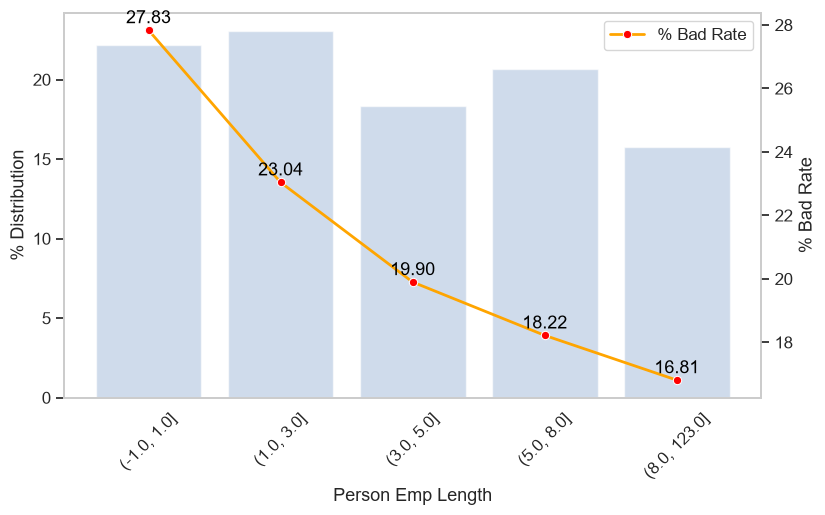

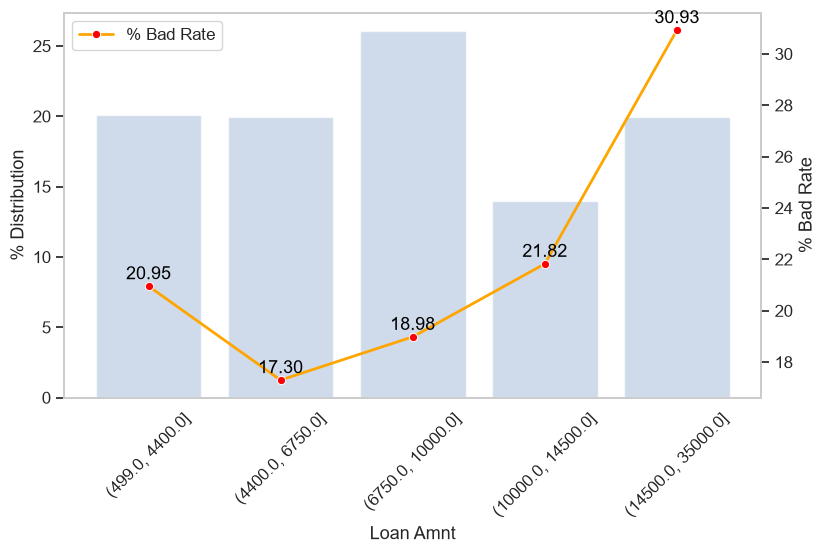

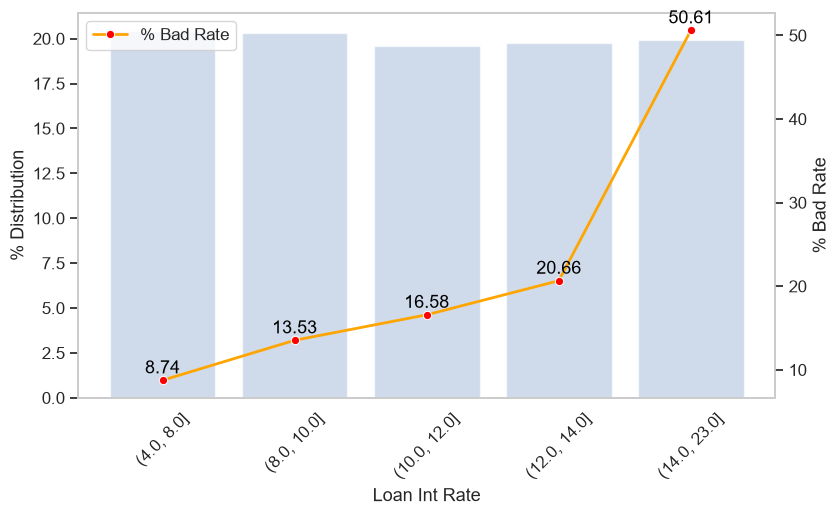

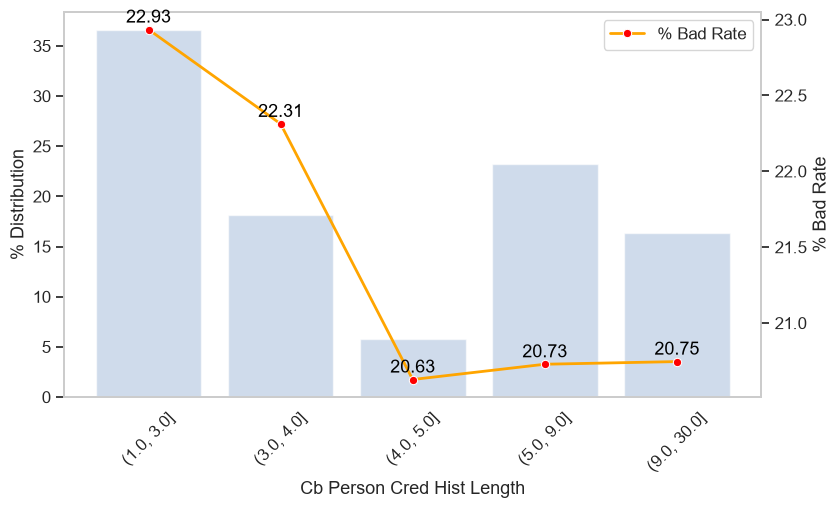

In [19]:
df_plot = df.copy()

for i in df_plot._get_numeric_data().columns:
  if i == 'loan_status':
    pass
  else:

    ### Generate dataframe for visualization ###

    df_group = df_plot[['loan_status', i]]
    df_group['bin_'+i] = pd.qcut(df_group[i].astype(float), q=5, duplicates='drop', precision=0)
    df_group = df_group.groupby('bin_'+i).agg({'loan_status': ['count', 'sum']})
    df_group.columns = df_group.columns.map('_'.join)
    df_group['dist'] = df_group['loan_status_count']/df_group['loan_status_count'].sum()
    df_group['bad_rate'] = df_group['loan_status_sum']/df_group['loan_status_count']
    df_group = df_group.reset_index()
 
    x1 = df_group['bin_'+i].astype(str)
    x2 = df_group.index
    y1 = df_group['dist']*100
    y2 = df_group['bad_rate']*100

    sns.set(font_scale=1.1)
    sns.set_style("whitegrid")
    fig, ax1  = plt.subplots(figsize=(9,5))
    plt.tick_params(axis='x', rotation = 45)

    ### y axis (left) is bar plot ###

    ax1.bar(x1,y1, data = df_group, color='lightsteelblue', alpha=.6)

    ### y axis (right) is line chart ###
    ax2 = ax1.twinx()
    ax2 = sns.lineplot(x=x2, y=y2, marker='o',\
                    markerfacecolor='red', markersize=6, color='orange', 
                    linewidth=2, label='% Bad Rate')
    ax1.set_xlabel(i.replace("_"," ").title())
    ax1.set_ylabel('% Distribution')
    ax2.set_ylabel('% Bad Rate')
    ax1.grid(False)
    ax2.grid(False)

    for x,y in zip(x2,y2):
            label = "{:.2f}".format(y)
            plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,5), ha='center', color='black') 


    plt.show();


### Feature engineering

In [20]:
# debt service ratio or DSR
df['dsr'] = df['loan_amnt']/df['person_income']

C:\Users\User\AppData\Local\Temp\ipykernel_920\1898394141.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['dsr'], kde=False)


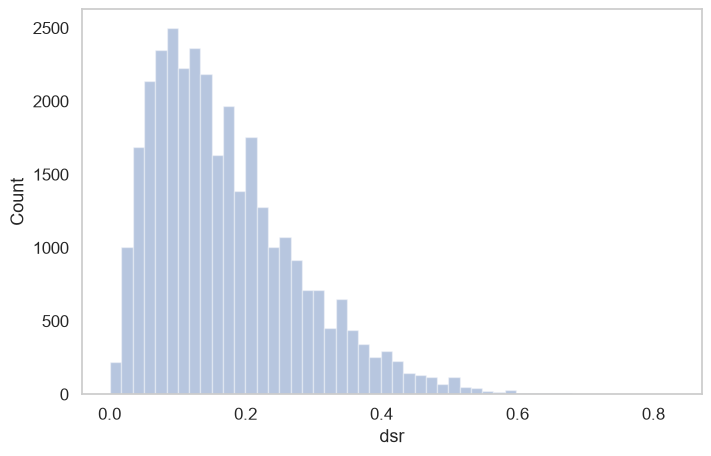

In [21]:
plt.subplots(figsize=(8,5))
sns.distplot(df['dsr'], kde=False)
plt.grid(False)
plt.ylabel('Count')
plt.show()

In [22]:
df.groupby('loan_intent').agg({'dsr': ['min', 'mean', 'median', 'max']})

dsr                              
                        min      mean    median       max
loan_intent                                              
DEBTCONSOLIDATION  0.004444  0.170800  0.147494  0.711538
EDUCATION          0.005464  0.170141  0.148221  0.771154
HOMEIMPROVEMENT    0.001282  0.165322  0.143223  0.700000
MEDICAL            0.005072  0.175195  0.151515  0.777083
PERSONAL           0.000789  0.169180  0.147692  0.830000
VENTURE            0.004143  0.170490  0.147368  0.714286

In [23]:
df.loc[df['dsr']>0.8]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,cb_person_default_on_file,cb_person_cred_hist_length,dsr
customer_id,,,,,,,,,,,,
0ab3438d-8c0f-4fb2-a394-388e88a2835a,22,20000,MORTGAGE,0.0,PERSONAL,B,16600,9.76,1,N,3,0.83


In [24]:
df_dsr = df[['loan_status', 'dsr']]
df_dsr['bin_dsr'] = pd.qcut(df_dsr['dsr'].astype(float), q=5, duplicates='drop', precision=0)
df_dsr = df_dsr.groupby('bin_dsr').agg({'loan_status': ['count', 'sum']})
df_dsr.columns = df_dsr.columns.map('_'.join)
df_dsr['dist'] = df_dsr['loan_status_count']/df_dsr['loan_status_count'].sum()
df_dsr['bad_rate'] = df_dsr['loan_status_sum']/df_dsr['loan_status_count']
df_dsr = df_dsr.reset_index()
df_dsr

,bin_dsr,loan_status_count,loan_status_sum,dist,bad_rate
0,"(-0.09920000000000001, 0.08]",6524,694,0.200239,0.106376
1,"(0.08, 0.1]",6510,818,0.199810,0.125653
2,"(0.1, 0.2]",6515,956,0.199963,0.146738
3,"(0.2, 0.3]",6517,1233,0.200025,0.189197
4,"(0.3, 0.8]",6515,3408,0.199963,0.523101


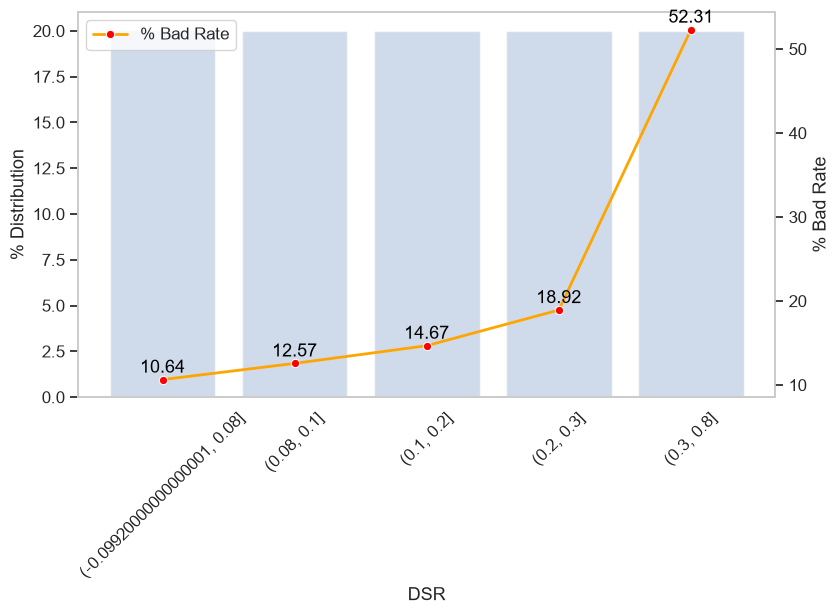

In [25]:
x1 = df_dsr['bin_dsr'].astype(str)
x2 = df_dsr.index
y1 = df_dsr['dist']*100
y2 = df_dsr['bad_rate']*100

sns.set(font_scale=1.1)
sns.set_style("whitegrid")
fig, ax1  = plt.subplots(figsize=(9,5))
plt.tick_params(axis='x', rotation = 45)

ax1.bar(x1,y1, data = df_dsr, color='lightsteelblue', alpha=.6)
ax1.xaxis.grid()
ax2 = ax1.twinx()
ax2 = sns.lineplot(x=x2, y=y2, marker='o',\
                markerfacecolor='red', markersize=6, color='orange', 
                linewidth=2, label='% Bad Rate')
ax1.set_xlabel('DSR')
ax1.set_ylabel('% Distribution')
ax2.set_ylabel('% Bad Rate')
ax1.grid(False)
ax2.grid(False)

for x,y in zip(x2,y2):
        label = "{:.2f}".format(y)
        plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,5), ha='center', color='black') 


plt.show();

### Weight of Evidence (WOE) & Information Value (IV)

In [26]:
def fill_missing(df):

  for col in df.columns: 
    if  df[col].dtypes == np.object_ : 
      df[col] = df[col].fillna(value='Unidentified')
      
    elif df[col].dtypes == np.number:
      df[col] = df[col].fillna(df[col].median()) 

  return df

In [27]:
df_clean = fill_missing(df)
df_clean.info()

<class 'pandas.DataFrame'>
Index: 32581 entries, 616d39c7-4cca-4e2e-a65c-848a9543cfe1 to 5185b116-af1e-4951-b9f0-d9d1f0d79b3e
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   cb_person_default_on_file   32581 non-null  str    
 10  cb_person_cred_hist_length  32581 non-null  int64  
 11  dsr                         32581 non-null  float64
dtypes: float64(3), int64(5), str(4)
memory

In [28]:
def binning_numeric(df):
  
  for i in df._get_numeric_data().columns:
    if i == 'loan_status':
      continue
    else:
      df[i] = pd.qcut(df[i].astype(float), q=5, duplicates='drop', precision=0).astype('object')

  return df_clean


In [29]:
df_bin = binning_numeric(df_clean)
df_bin.info()

<class 'pandas.DataFrame'>
Index: 32581 entries, 616d39c7-4cca-4e2e-a65c-848a9543cfe1 to 5185b116-af1e-4951-b9f0-d9d1f0d79b3e
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   person_age                  32581 non-null  object
 1   person_income               32581 non-null  object
 2   person_home_ownership       32581 non-null  str   
 3   person_emp_length           31686 non-null  object
 4   loan_intent                 32581 non-null  str   
 5   loan_grade                  32581 non-null  str   
 6   loan_amnt                   32581 non-null  object
 7   loan_int_rate               29465 non-null  object
 8   loan_status                 32581 non-null  int64 
 9   cb_person_default_on_file   32581 non-null  str   
 10  cb_person_cred_hist_length  32581 non-null  object
 11  dsr                         32581 non-null  object
dtypes: int64(1), object(7), str(4)
memory usage: 4.2+ MB

In [30]:
df_woe = df_bin.copy()
df_woe.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,cb_person_default_on_file,cb_person_cred_hist_length,dsr
customer_id,,,,,,,,,,,,
616d39c7-4cca-4e2e-a65c-848a9543cfe1,"(19.0, 23.0]","(49000.0, 63000.0]",RENT,"(8.0, 123.0]",PERSONAL,D,"(14500.0, 35000.0]","(14.0, 23.0]",1,Y,"(1.0, 3.0]","(0.3, 0.8]"
49d00b80-f7ec-41ec-8063-8cc32f384268,"(19.0, 23.0]","(3999.0, 35000.0]",OWN,"(3.0, 5.0]",EDUCATION,B,"(499.0, 4400.0]","(10.0, 12.0]",0,N,"(1.0, 3.0]","(0.08, 0.1]"
25172c7f-160a-44ac-b271-5833b7a679f6,"(23.0, 25.0]","(3999.0, 35000.0]",MORTGAGE,"(-1.0, 1.0]",MEDICAL,C,"(4400.0, 6750.0]","(12.0, 14.0]",1,N,"(1.0, 3.0]","(0.3, 0.8]"
a8f721ac-9696-48b3-ae35-bc8b13592d26,"(19.0, 23.0]","(63000.0, 86000.0]",RENT,"(3.0, 5.0]",MEDICAL,C,"(14500.0, 35000.0]","(14.0, 23.0]",1,N,"(1.0, 3.0]","(0.3, 0.8]"
53be6c0c-0a33-41c1-a8d0-e9784b077f98,"(23.0, 25.0]","(49000.0, 63000.0]",RENT,"(5.0, 8.0]",MEDICAL,C,"(14500.0, 35000.0]","(14.0, 23.0]",1,Y,"(3.0, 4.0]","(0.3, 0.8]"


In [31]:
d = pd.DataFrame(df_woe.groupby(['person_age']).size(), columns=['total'])

d['count_bad'] = df_woe.groupby(['person_age'])['loan_status'].sum()
d['count_good'] = d['total']-d['count_bad']

d['dist_bad'] = d['count_bad']/d['count_bad'].sum()
d['dist_good'] = d['count_good']/d['count_good'].sum()

d['woe'] = np.log(d.dist_bad/d.dist_good)
d["iv"] = (d.dist_bad-d.dist_good)*np.log(d.dist_bad/d.dist_good)

d = d.replace([np.inf, -np.inf], 0)
d = d.reset_index()

d

,person_age,total,count_bad,count_good,dist_bad,dist_good,woe,iv
0,"(19.0, 23.0]",8766,2092,6674,0.294275,0.262013,0.116119,0.003746
1,"(23.0, 25.0]",6586,1444,5142,0.203123,0.201869,0.006193,0.000008
2,"(25.0, 27.0]",4615,961,3654,0.135181,0.143452,-0.059385,0.000491
3,"(27.0, 32.0]",6963,1445,5518,0.203263,0.216630,-0.063688,0.000851
4,"(32.0, 144.0]",5651,1167,4484,0.164158,0.176036,-0.069861,0.000830


In [32]:
d['iv'].sum()

np.float64(0.0059262581959489595)

In [33]:
woe_dict = d.groupby(['person_age'])['woe'].mean().to_dict()
woe_dict

{Interval(19.0, 23.0, closed='right'): 0.11611938858812067,
 Interval(23.0, 25.0, closed='right'): 0.006193154341563288,
 Interval(25.0, 27.0, closed='right'): -0.05938510525303306,
 Interval(27.0, 32.0, closed='right'): -0.06368793151607242,
 Interval(32.0, 144.0, closed='right'): -0.0698609291908682}

In [34]:
df_demo_woe = df_woe[['person_age']]
df_demo_woe['woe_person_age'] = df_demo_woe['person_age'].map(woe_dict)
df_demo_woe.sample(10)

,person_age,woe_person_age
customer_id,,
fbfafca8-2cb5-449a-a8fe-20d14acae8ed,"(19.0, 23.0]",0.116119
23ec673a-3dcf-4162-ae61-3c243665c0d6,"(19.0, 23.0]",0.116119
d0ea5c64-1f4c-4fc5-9525-bce1fccfd74e,"(23.0, 25.0]",0.006193
5bfe7990-f2f8-4db5-8b2d-b4a428eccaf8,"(25.0, 27.0]",-0.059385
ad9540d8-2fcf-48a2-affa-d54837c6dc1a,"(23.0, 25.0]",0.006193
114834f2-a771-4841-a89d-ad56c7380d37,"(27.0, 32.0]",-0.063688
42ffd947-140d-4c69-8b11-f6e57286828e,"(25.0, 27.0]",-0.059385
27ae70fe-34ed-4a77-8c53-551fa0f8feec,"(25.0, 27.0]",-0.059385
8bba21e8-23c6-4fbb-a230-858fa2725604,"(27.0, 32.0]",-0.063688


In [35]:
def woe_iv(df_woe):

  iv_dict = {}
  final_iv = {}

  for i in df_woe.select_dtypes(object).columns:

    ### Calculate WOE and IV ###
    d = pd.DataFrame(df_woe.groupby([i]).size(), columns=['total'])

    d['count_bad'] = df_woe.groupby([i])['loan_status'].sum()
    d['count_good'] = d['total']-d['count_bad']

    d['dist_bad'] = d['count_bad']/d['count_bad'].sum()
    d['dist_good'] = d['count_good']/d['count_good'].sum()
    
    d['woe'] = np.log(d.dist_bad/d.dist_good)
    d["iv"] = (d.dist_bad-d.dist_good)*np.log(d.dist_bad/d.dist_good)

    d = d.replace([np.inf, -np.inf], 0)
    d = d.reset_index()
    
    ### Append dataframe in dictionary ###
    if i not in final_iv:
      final_iv[i] = []
    final_iv[i].append(d)
    
    ### Map WOE value ###
    woe_dict = d.groupby([i])['woe'].mean().to_dict()
    df_woe['woe_'+i] = df_woe[i].map(woe_dict).fillna(0)
    
    ### Calculate final IV of each feature and append in dictionary
    if i not in iv_dict:
      iv_dict[i] = []
    iv_dict[i].append(d['iv'].sum())
  
  ### Generate IV dataframe
  iv_df = pd.DataFrame.from_dict(iv_dict, orient='index', columns=['IV'])
  iv_df.index.name = 'Feature'

  return final_iv, iv_df, df_woe

In [36]:
final_iv, IV, df_woe = woe_iv(df_woe)

C:\Users\User\AppData\Local\Temp\ipykernel_920\3200485961.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in df_woe.select_dtypes(object).columns:


In [37]:
final_iv['person_income']

[          person_income  total  count_bad  count_good  dist_bad  dist_good  \
 0     (3999.0, 35000.0]   6630       2869        3761  0.403573   0.147652   
 1    (35000.0, 49000.0]   6546       1535        5011  0.215923   0.196726   
 2    (49000.0, 63000.0]   6397       1164        5233  0.163736   0.205441   
 3    (63000.0, 86000.0]   6515        948        5567  0.133352   0.218554   
 4  (86000.0, 6000000.0]   6493        593        5900  0.083415   0.231627   
 
         woe        iv  
 0  1.005497  0.257327  
 1  0.093113  0.001788  
 2 -0.226904  0.009463  
 3 -0.494039  0.042093  
 4 -1.021295  0.151368  ]

In [38]:
IV.sort_values(by='IV', ascending=False)

,IV
Feature,
loan_grade,0.881539
dsr,0.719621
loan_int_rate,0.681578
person_income,0.462039
person_home_ownership,0.376710
cb_person_default_on_file,0.163922
loan_intent,0.095705
loan_amnt,0.073652
person_emp_length,0.053639


In [39]:
df_woe.info()

<class 'pandas.DataFrame'>
Index: 32581 entries, 616d39c7-4cca-4e2e-a65c-848a9543cfe1 to 5185b116-af1e-4951-b9f0-d9d1f0d79b3e
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      32581 non-null  object 
 1   person_income                   32581 non-null  object 
 2   person_home_ownership           32581 non-null  str    
 3   person_emp_length               31686 non-null  object 
 4   loan_intent                     32581 non-null  str    
 5   loan_grade                      32581 non-null  str    
 6   loan_amnt                       32581 non-null  object 
 7   loan_int_rate                   29465 non-null  object 
 8   loan_status                     32581 non-null  int64  
 9   cb_person_default_on_file       32581 non-null  str    
 10  cb_person_cred_hist_length      32581 non-null  object 
 11  dsr                             32581 non-n

In [40]:
df_woe.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,cb_person_default_on_file,...,woe_person_income,woe_person_home_ownership,woe_person_emp_length,woe_loan_intent,woe_loan_grade,woe_loan_amnt,woe_loan_int_rate,woe_cb_person_default_on_file,woe_cb_person_cred_hist_length,woe_dsr
customer_id,,,,,,,,,,,,,,,,,,,,,
616d39c7-4cca-4e2e-a65c-848a9543cfe1,"(19.0, 23.0]","(49000.0, 63000.0]",RENT,"(8.0, 123.0]",PERSONAL,D,"(14500.0, 35000.0]","(14.0, 23.0]",1,Y,...,-0.226904,0.502614,-0.307041,-0.115973,1.642076,0.472619,1.293632,0.778461,0.064186,1.368686
49d00b80-f7ec-41ec-8063-8cc32f384268,"(19.0, 23.0]","(3999.0, 35000.0]",OWN,"(3.0, 5.0]",EDUCATION,B,"(499.0, 4400.0]","(10.0, 12.0]",0,N,...,1.005497,-1.240559,-0.100416,-0.294121,-0.360917,-0.051501,-0.346798,-0.213465,0.064186,-0.663736
25172c7f-160a-44ac-b271-5833b7a679f6,"(23.0, 25.0]","(3999.0, 35000.0]",MORTGAGE,"(-1.0, 1.0]",MEDICAL,C,"(4400.0, 6750.0]","(12.0, 14.0]",1,N,...,1.005497,-0.662570,0.339662,0.266357,-0.064818,-0.288606,-0.076633,-0.213465,0.064186,1.368686
a8f721ac-9696-48b3-ae35-bc8b13592d26,"(19.0, 23.0]","(63000.0, 86000.0]",RENT,"(3.0, 5.0]",MEDICAL,C,"(14500.0, 35000.0]","(14.0, 23.0]",1,N,...,-0.494039,0.502614,-0.100416,0.266357,-0.064818,0.472619,1.293632,-0.213465,0.064186,1.368686
53be6c0c-0a33-41c1-a8d0-e9784b077f98,"(23.0, 25.0]","(49000.0, 63000.0]",RENT,"(5.0, 8.0]",MEDICAL,C,"(14500.0, 35000.0]","(14.0, 23.0]",1,Y,...,-0.226904,0.502614,-0.209412,0.266357,-0.064818,0.472619,1.293632,0.778461,0.028656,1.368686


In [41]:
def iv_group(df):
  
    if df['IV'] > 0.5:
        val = 'Suspicious'
    elif df['IV'] > 0.3 and df['IV'] <= 0.5 :
        val = 'Strong'
    elif df['IV'] > 0.1 and df['IV'] <= 0.3 :
        val = 'Medium'
    elif df['IV'] > 0.02 and df['IV'] <= 0.1 :
        val = 'Weak'
    else:
        val = 'Not useful'

    return val

IV['Predictive_Power'] = IV.apply(iv_group, axis=1)
IV.sort_values('IV',ascending=False)

,IV,Predictive_Power
Feature,,
loan_grade,0.881539,Suspicious
dsr,0.719621,Suspicious
loan_int_rate,0.681578,Suspicious
person_income,0.462039,Strong
person_home_ownership,0.376710,Strong
cb_person_default_on_file,0.163922,Medium
loan_intent,0.095705,Weak
loan_amnt,0.073652,Weak
person_emp_length,0.053639,Weak


### Data partition

In [42]:
X = df_woe.loc[:, df_woe.columns.str.startswith('woe_')]
y = df_woe['loan_status']

In [43]:
X.head()

,woe_person_age,woe_person_income,woe_person_home_ownership,woe_person_emp_length,woe_loan_intent,woe_loan_grade,woe_loan_amnt,woe_loan_int_rate,woe_cb_person_default_on_file,woe_cb_person_cred_hist_length,woe_dsr
customer_id,,,,,,,,,,,
616d39c7-4cca-4e2e-a65c-848a9543cfe1,0.116119,-0.226904,0.502614,-0.307041,-0.115973,1.642076,0.472619,1.293632,0.778461,0.064186,1.368686
49d00b80-f7ec-41ec-8063-8cc32f384268,0.116119,1.005497,-1.240559,-0.100416,-0.294121,-0.360917,-0.051501,-0.346798,-0.213465,0.064186,-0.663736
25172c7f-160a-44ac-b271-5833b7a679f6,0.006193,1.005497,-0.662570,0.339662,0.266357,-0.064818,-0.288606,-0.076633,-0.213465,0.064186,1.368686
a8f721ac-9696-48b3-ae35-bc8b13592d26,0.116119,-0.494039,0.502614,-0.100416,0.266357,-0.064818,0.472619,1.293632,-0.213465,0.064186,1.368686
53be6c0c-0a33-41c1-a8d0-e9784b077f98,0.006193,-0.226904,0.502614,-0.209412,0.266357,-0.064818,0.472619,1.293632,0.778461,0.028656,1.368686


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)
    
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

loan_status
0    0.781806
1    0.218194
Name: proportion, dtype: float64
loan_status
0    0.781801
1    0.218199
Name: proportion, dtype: float64


### Train logistic regression

In [45]:
import statsmodels.api as sm

In [46]:

nan_counts = X_train.isna().sum()
print("NaN:\n", nan_counts[nan_counts > 0])


inf_mask = X_train.isin([np.inf, -np.inf])
print("\nInf:\n", inf_mask.sum()[inf_mask.sum() > 0])


print("\ny_train NaN:", y_train.isna().sum())

NaN:
 Series([], dtype: int64)

Inf:
 Series([], dtype: int64)

y_train NaN: 0


In [47]:
import io

model = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=True, 
                                                        maxiter=100,
                                                        intercept=True)

model.summary()

results_as_html = model.summary().tables[1].as_html()

summary = pd.read_html(io.StringIO(results_as_html), header=0, index_col=0)[0]
summary['Feature'] = summary.index
summary = summary.reset_index(drop=True)
summary['Feature'] = summary['Feature'].str.replace('woe_', '')
summary = summary.set_index(['Feature'], drop=True)
summary

Optimization terminated successfully.
         Current function value: 0.343382
         Iterations 7


d:\ML_for_Business\.venv\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: intercept. After release 0.14, this will raise.
  warnings.warn(


,coef,std err,z,P>|z|,[0.025,0.975]
Feature,,,,,,
const,-1.3468,0.020,-67.024,0.000,-1.386,-1.307
person_age,0.4601,0.371,1.241,0.214,-0.266,1.187
person_income,0.9425,0.035,26.751,0.000,0.873,1.012
person_home_ownership,0.8796,0.032,27.127,0.000,0.816,0.943
person_emp_length,0.2152,0.086,2.488,0.013,0.046,0.385
loan_intent,1.3551,0.063,21.519,0.000,1.232,1.478
loan_grade,1.1134,0.036,30.877,0.000,1.043,1.184
loan_amnt,0.7465,0.091,8.176,0.000,0.568,0.925
loan_int_rate,0.0785,0.043,1.842,0.065,-0.005,0.162


In [48]:
def train_model(X_train, y_train):
    ### Fit logistic regression ###
    model = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=True, 
                                                            maxiter=100,
                                                            intercept=True)
    
    ### Generate model summary (วิธีใหม่: ดึงข้อมูลตรงจากตาราง ไม่ต้องแปลง HTML) ###
    table = model.summary().tables[1]
    
    # นำข้อมูลจากตารางมาสร้างเป็น DataFrame
    summary = pd.DataFrame(table.data[1:], columns=table.data[0])
    
    # ตั้งค่าให้คอลัมน์แรกเป็น Index 
    summary = summary.set_index(summary.columns[0])
    summary.index.name = None 
    
    # คลีนชื่อ Feature เหมือนเดิม
    summary['Feature'] = summary.index
    summary = summary.reset_index(drop=True)
    summary['Feature'] = summary['Feature'].str.replace('woe_', '')
    summary = summary.set_index(['Feature'], drop=True)

    return model, summary

In [49]:
lr, lr_summary = train_model(X_train, y_train)

Optimization terminated successfully.
         Current function value: 0.343382
         Iterations 7


d:\ML_for_Business\.venv\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: intercept. After release 0.14, this will raise.
  warnings.warn(


In [50]:
lr_summary

,coef,std err,z,P>|z|,[0.025,0.975]
Feature,,,,,,
const,-1.3468,0.020,-67.024,0.000,-1.386,-1.307
person_age,0.4601,0.371,1.241,0.214,-0.266,1.187
person_income,0.9425,0.035,26.751,0.000,0.873,1.012
person_home_ownership,0.8796,0.032,27.127,0.000,0.816,0.943
person_emp_length,0.2152,0.086,2.488,0.013,0.046,0.385
loan_intent,1.3551,0.063,21.519,0.000,1.232,1.478
loan_grade,1.1134,0.036,30.877,0.000,1.043,1.184
loan_amnt,0.7465,0.091,8.176,0.000,0.568,0.925
loan_int_rate,0.0785,0.043,1.842,0.065,-0.005,0.162


[How to interpret logistic regression results](https://towardsdatascience.com/logistic-regression-model-fitting-and-finding-the-correlation-p-value-z-score-confidence-8330fb86db19)

### Predict results

In [51]:
y_pred_train = lr.predict(sm.add_constant(X_train))
y_pred_test = lr.predict(sm.add_constant(X_test))

y_pred_test

customer_id
a7ffec61-d78c-4432-8a0c-3c45c15d52dd    0.137841
e4811ccc-a5d6-4736-89d9-8c44798637be    0.160451
353355c6-4fc3-4474-a53d-272968f0cb70    0.018690
0350a780-fe5b-451f-95e0-fb8819461c1a    0.055940
56bae8b4-16c7-4790-9f2a-6aec3e8604c0    0.003880
                                          ...   
bfc11849-7cb3-4fbd-a919-9270f2a1c725    0.003802
fa392284-258f-419f-bb25-5abe3b6f5ecc    0.010884
2ec5fb34-1178-4a50-a295-b32b561d74d3    0.021769
36589fd9-ae25-4485-bd3c-2e2ac47bf601    0.767991
7cb74578-1da4-49bb-b9a2-2cdb97e48f86    0.910448
Length: 6517, dtype: float64

### Variance Inflation Factor (VIF)

In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [53]:
features = X.copy()
features.columns = features.columns.str.replace('woe_', '')
features = features.assign(const=1)
features

vif = pd.DataFrame()
vif["Feature"] = features.columns
vif["VIF Factor"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
vif

,Feature,VIF Factor
0,person_age,2.276472
1,person_income,1.570417
2,person_home_ownership,1.104273
3,person_emp_length,1.075882
4,loan_intent,1.017082
5,loan_grade,3.052888
6,loan_amnt,1.607443
7,loan_int_rate,3.069078
8,cb_person_default_on_file,1.327012
9,cb_person_cred_hist_length,2.231233


In [54]:
def vif_calculation(X):
  
  features = X.copy()
  features.columns = features.columns.str.replace('woe_', '')
  features = features.assign(const=1)

  vif = pd.DataFrame()
  vif["Feature"] = features.columns
  vif["VIF Factor"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
  
  return vif


In [55]:
vif = vif_calculation(X)
vif

,Feature,VIF Factor
0,person_age,2.276472
1,person_income,1.570417
2,person_home_ownership,1.104273
3,person_emp_length,1.075882
4,loan_intent,1.017082
5,loan_grade,3.052888
6,loan_amnt,1.607443
7,loan_int_rate,3.069078
8,cb_person_default_on_file,1.327012
9,cb_person_cred_hist_length,2.231233


### Model evaluation

In [56]:
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, classification_report

In [57]:
def roc_gini(y, y_pred_proba):

  assert y.shape == y_pred_proba.shape
  fpr, tpr, _ = metrics.roc_curve(y, y_pred_proba)
  auc = metrics.roc_auc_score(y, y_pred_proba)
  gini = (2 * auc - 1)*100

  fig = plt.figure(figsize=(8,6))
  plt.plot(fpr, tpr, color='C0', label='%s AUC = %0.4f, Gini = %0.2f' % ('Model: ', auc,  gini), 
           linewidth=2.5)
  plt.plot([0, 1], [0, 1], color='darkgrey', linestyle='--', linewidth=2)
  plt.xlim([-0.01, 1.01])
  plt.ylim([-0.01, 1.01])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.legend(loc='lower right',fontsize='small')
  plt.grid(False)
  plt.show()

Training set


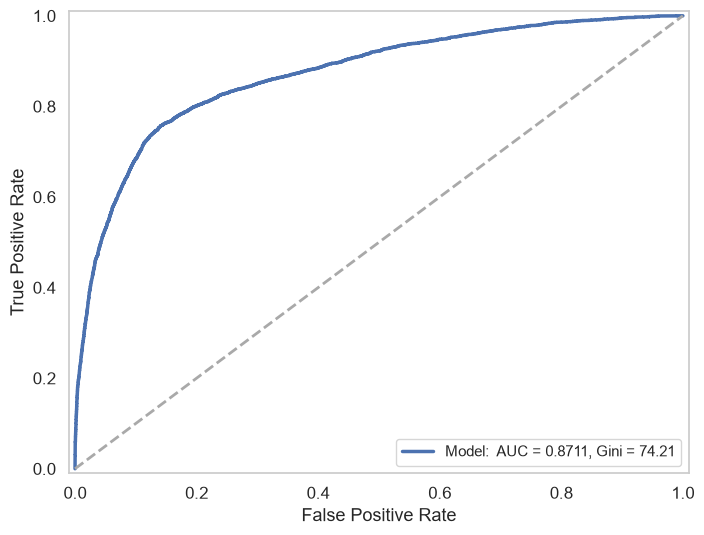

Test set


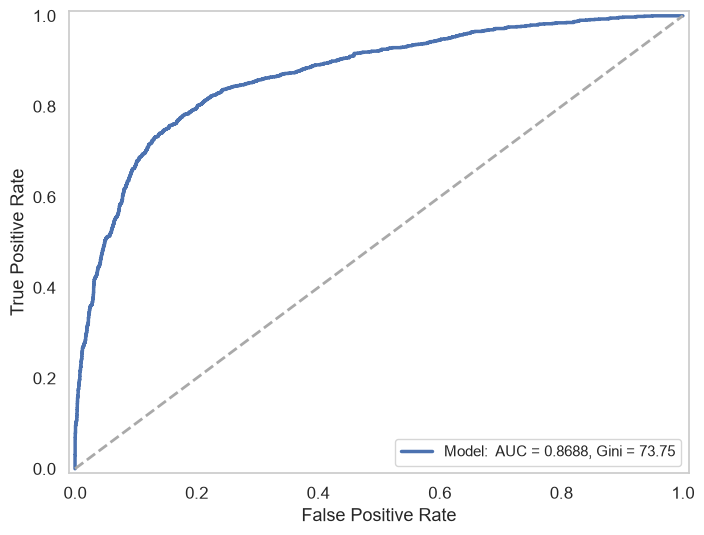

In [58]:
print('Training set')
roc_gini(y_train.values, y_pred_train)
    
print('Test set')
roc_gini(y_test.values, y_pred_test)

### Summary overall of model

In [61]:
def summary_model(IV, vif, summary):
    
    summary_model = IV.merge(vif, left_on= 'Feature', right_on='Feature').merge(lr_summary ,on='Feature')
    summary_model = summary_model.rename(columns={'P>|z|': "p-value", "VIF Factor": "vif", "IV":"iv"})
    summary_model['coef'] = pd.to_numeric(summary_model['coef'], errors='coerce')
    ### calculate feature importance ###
    summary_model['feature_importance'] = (summary_model['coef'].abs()/summary_model['coef'].abs().sum())*100
    
    return summary_model

In [62]:
summary = summary_model(IV, vif, lr_summary)
summary

,Feature,iv,Predictive_Power,vif,coef,std err,z,p-value,[0.025,0.975],feature_importance
0,person_age,0.005926,Not useful,2.276472,0.4601,0.371,1.241,0.214,-0.266,1.187,6.664349
1,person_income,0.462039,Strong,1.570417,0.9425,0.035,26.751,0.000,0.873,1.012,13.651704
2,person_home_ownership,0.376710,Strong,1.104273,0.8796,0.032,27.127,0.000,0.816,0.943,12.740625
3,person_emp_length,0.053639,Weak,1.075882,0.2152,0.086,2.488,0.013,0.046,0.385,3.117079
4,loan_intent,0.095705,Weak,1.017082,1.3551,0.063,21.519,0.000,1.232,1.478,19.628036
5,loan_grade,0.881539,Suspicious,3.052888,1.1134,0.036,30.877,0.000,1.043,1.184,16.127117
6,loan_amnt,0.073652,Weak,1.607443,0.7465,0.091,8.176,0.000,0.568,0.925,10.812729
7,loan_int_rate,0.681578,Suspicious,3.069078,0.0785,0.043,1.842,0.065,-0.005,0.162,1.137038
8,cb_person_default_on_file,0.163922,Medium,1.327012,-0.0539,0.050,-1.070,0.285,-0.153,0.045,0.780718
9,cb_person_cred_hist_length,0.003596,Not useful,2.231233,0.2278,0.476,0.478,0.632,-0.705,1.161,3.299584


### Model tuning

Trick for tuning the logistic regression model

* Remove some features (p-value > 0.005)
* Remove some features (not risk ranking e.g. loan_amnt)
* Remove some features (low predictive power from IV e.g. not-useful)

In [64]:
summary['p-value'] = pd.to_numeric(summary['p-value'], errors='coerce')
summary['Feature'].loc[summary['p-value']>0.005].to_list()

['person_age',
 'person_emp_length',
 'loan_int_rate',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [65]:
X_2 = X.drop(['woe_cb_person_cred_hist_length', 'woe_cb_person_default_on_file', 
              'woe_person_age', 'woe_person_emp_length', 'woe_loan_int_rate',
              'woe_loan_amnt'], axis=1)
y_2 = df_woe['loan_status']

In [66]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=99, stratify=y)

In [67]:
lr_2, lr_2_summary = train_model(X_train_2, y_train_2)

Optimization terminated successfully.
         Current function value: 0.344957
         Iterations 7


d:\ML_for_Business\.venv\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: intercept. After release 0.14, this will raise.
  warnings.warn(


In [68]:
y_pred_train_2 = lr_2.predict(sm.add_constant(X_train_2))
y_pred_test_2 = lr_2.predict(sm.add_constant(X_test_2))

Training set


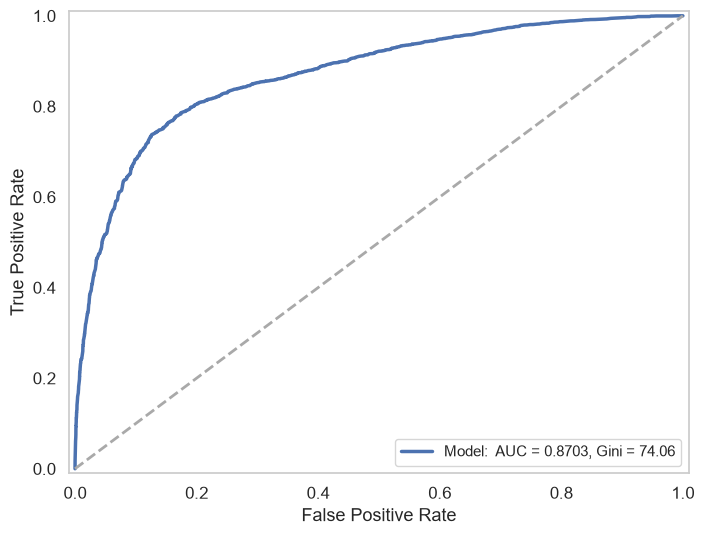

Test set


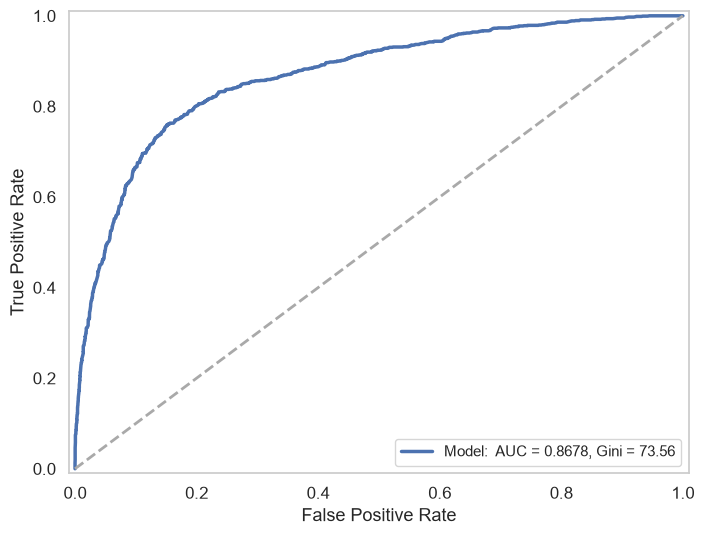

In [69]:
print('Training set')
roc_gini(y_train_2.values, y_pred_train_2)
    
print('Test set')
roc_gini(y_test_2.values, y_pred_test_2)

In [70]:
vif_2 = vif_calculation(X_2)
vif_2

,Feature,VIF Factor
0,person_income,1.170192
1,person_home_ownership,1.068363
2,loan_intent,1.003869
3,loan_grade,1.025455
4,dsr,1.133359
5,const,1.106320


In [71]:
summary_2 = summary_model(IV, vif_2, lr_2_summary)
summary_2.sort_values(by='feature_importance', ascending=False)

,Feature,iv,Predictive_Power,vif,coef,std err,z,p-value,[0.025,0.975],feature_importance
2,loan_intent,0.095705,Weak,1.003869,1.3551,0.063,21.519,0.000,1.232,1.478,26.456979
3,loan_grade,0.881539,Suspicious,1.025455,1.1134,0.036,30.877,0.000,1.043,1.184,21.738027
0,person_income,0.462039,Strong,1.170192,0.9425,0.035,26.751,0.000,0.873,1.012,18.401374
1,person_home_ownership,0.376710,Strong,1.068363,0.8796,0.032,27.127,0.000,0.816,0.943,17.173315
4,dsr,0.719621,Suspicious,1.133359,0.8313,0.026,31.843,0.000,0.780,0.882,16.230305


### Final model

Optimization terminated successfully.
         Current function value: 0.345974
         Iterations 7


d:\ML_for_Business\.venv\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: intercept. After release 0.14, this will raise.
  warnings.warn(


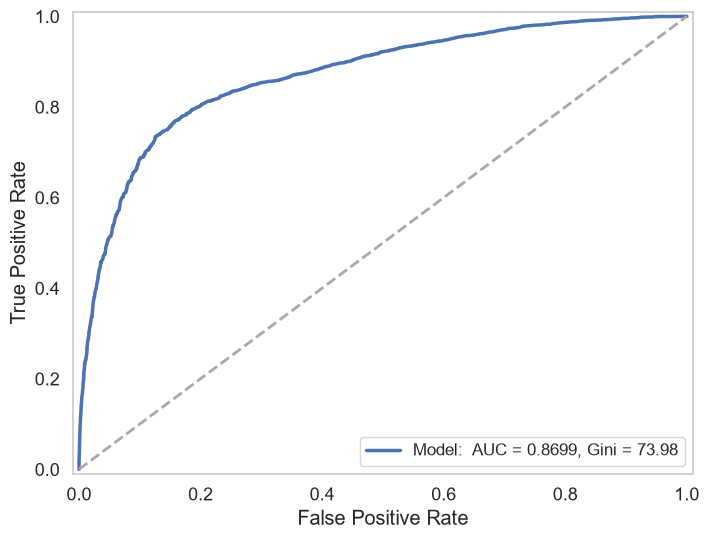

************************************************************
              precision    recall  f1-score   support

        Good       0.88      0.95      0.91     25472
         Bad       0.73      0.52      0.61      7109

    accuracy                           0.85     32581
   macro avg       0.80      0.73      0.76     32581
weighted avg       0.84      0.85      0.84     32581



In [72]:
X_final = X.drop(['woe_cb_person_cred_hist_length', 'woe_cb_person_default_on_file', 
              'woe_person_age', 'woe_person_emp_length', 'woe_loan_int_rate',
              'woe_loan_amnt'], axis=1)
y_final = df_woe['loan_status']

df_grade = df_woe.copy()
threshold = 0.5

final_model = sm.Logit(y_final, sm.add_constant(X_final)).fit(disp=True, maxiter=100, intercept=True)

df_grade['pd'] = final_model.predict(sm.add_constant(X_final))
df_grade['prediction'] = np.where(df_grade['pd'] >= threshold, 1, 0)

sns.set(font_scale=1.2)
sns.set_style("whitegrid")
roc_gini(y_final.values, df_grade['pd'].values)
print('*'*60)
target_names = ['Good', 'Bad']
print(classification_report(y_final.values, df_grade['prediction'].values, target_names=target_names))

### Save trained final model

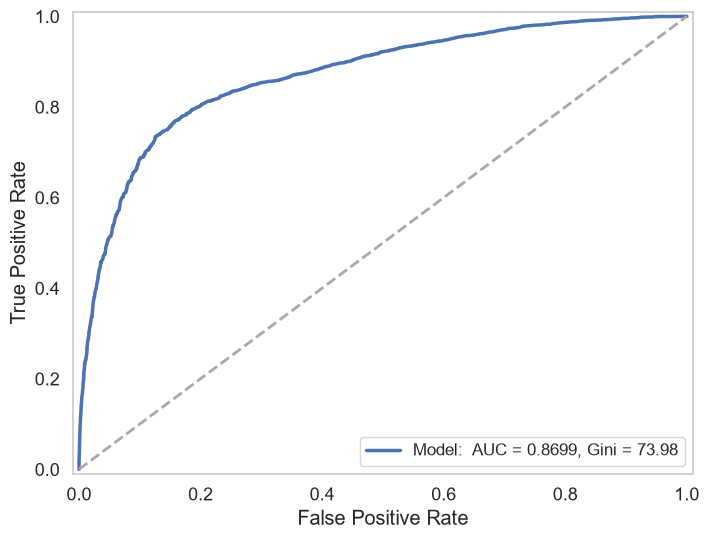

In [76]:
## save trained model using pickle format
final_model.save("model_credit_scoring/credit_scoring_lr.pickle")

## load trained model
trained_model = sm.load('model_credit_scoring/credit_scoring_lr.pickle')

roc_gini(y_final.values, trained_model.predict(sm.add_constant(X_final)).values)

### Score grading

C:\Users\User\AppData\Local\Temp\ipykernel_920\563913674.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_grade['pd'], kde=False, bins=30)


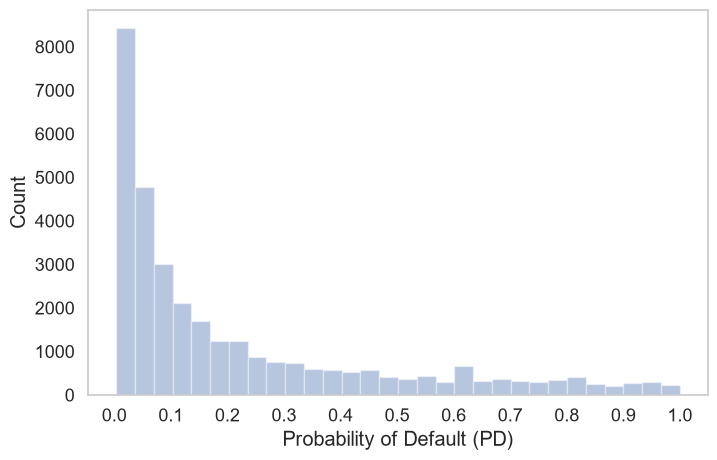

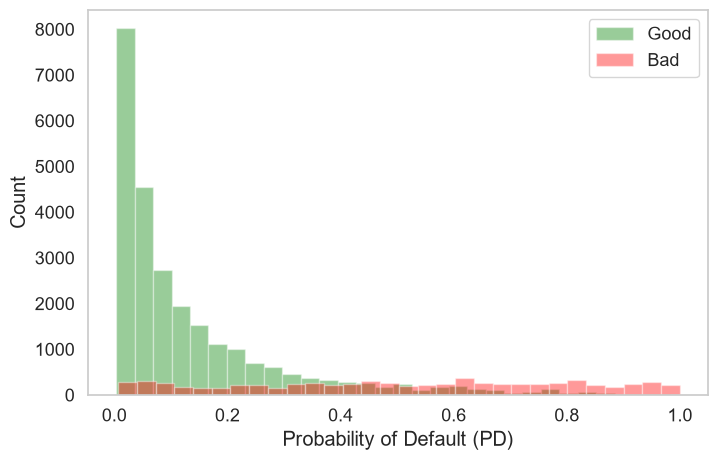

In [77]:
df_grade['score_grade'] = pd.cut(df_grade['pd'], 
                                      bins=[0, 0.05, 0.10, 0.15, 0.30, 0.50, 0.70, 1], 
                                      labels=['A', 'B', 'C', 'D', 'E', 'F', 'G'])

fig= plt.figure(figsize=(8,5))
sns.distplot(df_grade['pd'], kde=False, bins=30)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Count')
plt.grid(False)
plt.show();

x_good = df_grade['pd'].loc[df_grade['loan_status']==0].values
x_bad = df_grade['pd'].loc[df_grade['loan_status']==1].values

fig, ax = plt.subplots(figsize=(8,5))
ax = plt.hist(x_good, label='Good', bins=30, alpha=.4, color='green')
ax = plt.hist(x_bad, label='Bad', bins=30, alpha=.4, color='red')
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Count')
plt.legend()
plt.grid(False)
plt.show();

In [78]:
report = df_grade[['score_grade', 'loan_status']]
report = report.groupby('score_grade').agg({'loan_status': ['count', 'sum']})
report.columns = report.columns.map('_'.join)
report['dist'] = report['loan_status_count']/report['loan_status_count'].sum()
report['bad_rate'] = report['loan_status_sum']/report['loan_status_count']
report

,loan_status_count,loan_status_sum,dist,bad_rate
score_grade,,,,
A,10817,391,0.332003,0.036147
B,5225,411,0.160370,0.078660
C,3105,269,0.095301,0.086634
D,4988,812,0.153095,0.162791
E,3383,1526,0.103834,0.451079
F,2445,1515,0.075044,0.619632
G,2618,2185,0.080354,0.834607


In [79]:
def plot_score_grade(report):

  fig, ax = plt.subplots(figsize=(10,6))
  sns.set(font_scale=1.2)
  sns.set_style("whitegrid")

  x1 = report.index
  y1 = np.round(report['dist'].values*100, 2)
  x2 = x1
  y2 = np.round(report['bad_rate'].values*100, 2)

  ax.bar(x1,y1, data = report, color='lightsteelblue', label='% Distribution', alpha=.6)
  ax.yaxis.grid(False)
  ax.xaxis.grid(False)
  ax.set_xlabel('Score Grade')
  ax.set_ylabel('% Distribution')
  
  xlocs, xlabs = plt.xticks()
  plt.xticks(xlocs, xlabs)
  for i, v in enumerate(y1):
      plt.text(xlocs[i] - 0.2, v + 0.02, str(v))
   
  ax2 = ax.twinx()
  ax2 = sns.lineplot(data=report, x=x2, y=y2, marker='o', markerfacecolor='red', 
                     markersize=8, color='yellowgreen', linewidth=2.5, linestyle='-',
                     label='% Bad Rate')
  ax2.set_ylabel('% Bad Rate')
  ax2.yaxis.grid(False)
  ax2.xaxis.grid(False)
  ax.legend(loc='lower left', bbox_to_anchor=(0.27, 0.88))
  ax2.legend(loc='lower left', bbox_to_anchor=(0.54, 0.88))
  ax.set_ylim([0, 39])
  ax2.set_ylim([-0.5, 92])

  for x,y in zip(x2,y2):
          label = "{:.2f}".format(y)
          plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,5), ha='center', color='black') 

  plt.tight_layout(pad=3.0)

  plt.show();

  return

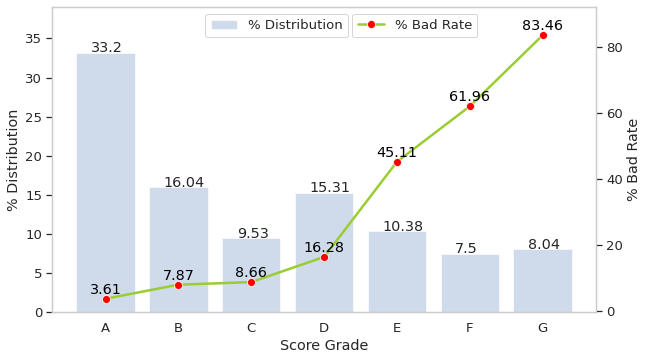

In [ ]:
plot_score_grade(report)

### Score impact and business suggestion

In [80]:
df_impact = df_grade[['loan_status', 'pd', 'prediction', 'score_grade']]
grade = 'A'

### Choose Cut-off 
print('Cut-off is {}'.format(grade))
print('*'*40)
df_impact['status'] = np.where(df_impact['pd']<=0.05, 'Approved', 'Rejected')
        
### Calculate % approval rate ###
approve = df_impact.loc[(df_impact['status']=='Approved')].shape[0]
reject = df_impact.loc[(df_impact['status']=='Rejected')].shape[0]
approval_rate = np.round((approve/(approve+reject))*100,2)
print('Total = {}'.format(approve+reject))
print('Approved = {}'.format(approve))
print('Rejected = {}'.format(reject))
print('Approval rate = {} %'.format(approval_rate))
print('*'*40)

### Calculate % bad rate ###
bad = df_impact.loc[(df_impact['status']=='Approved')&(df_impact['loan_status']==1)].shape[0]
good = df_impact.loc[(df_impact['status']=='Approved')&(df_impact['loan_status']==0)].shape[0]
bad_rate = np.round((bad/(good+bad))*100,2)
print('Bad = {}'.format(bad))
print('Good = {}'.format(good))
print('Bad rate = {} %'.format(bad_rate))

print('*'*40)

Cut-off is A
****************************************
Total = 32581
Approved = 10817
Rejected = 21764
Approval rate = 33.2 %
****************************************
Bad = 391
Good = 10426
Bad rate = 3.61 %
****************************************


In [81]:
def cut_off(df_grade):

    df_impact = df_grade.copy()
    cut_off_grade = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    cut_off_pd = [0.05, 0.1, 0.15, 0.3, 0.5, 0.7, 1]
    rows = []
    for i in cut_off_pd:
        df_impact['status'] = np.where(df_impact['pd']<=i, 'Approved', 'Rejected')
        
        ### Calculate % approval rate ###

        approve = df_impact.loc[(df_impact['status']=='Approved')].shape[0]
        reject = df_impact.loc[(df_impact['status']=='Rejected')].shape[0]
        approval_rate = np.round((approve/(approve+reject))*100,2)
        
        ### Calculate % bad rate ###
        bad = df_impact.loc[(df_impact['status']=='Approved')&(df_impact['loan_status']==1)].shape[0]
        good = df_impact.loc[(df_impact['status']=='Approved')&(df_impact['loan_status']==0)].shape[0]
        bad_rate = np.round((bad/(good+bad))*100,2)
        
        rows.append([i, approve, reject, approval_rate, good, bad, bad_rate])
        print(rows)

    df_cut_off = pd.DataFrame(rows, columns=["pd", "approved", "rejected", 
                                             "%_approval_rate", "good", "bad", "%_bad_rate"])
    df_cut_off['grade'] = cut_off_grade
    df_cut_off = df_cut_off[["grade", "pd", "approved", "rejected", 
                             "%_approval_rate", "good", "bad", "%_bad_rate"]]
    
    return df_cut_off

In [82]:
df_cut_off = cut_off(df_grade)
df_cut_off

[[0.05, 10817, 21764, np.float64(33.2), 10426, 391, np.float64(3.61)]]
[[0.05, 10817, 21764, np.float64(33.2), 10426, 391, np.float64(3.61)], [0.1, 16042, 16539, np.float64(49.24), 15240, 802, np.float64(5.0)]]
[[0.05, 10817, 21764, np.float64(33.2), 10426, 391, np.float64(3.61)], [0.1, 16042, 16539, np.float64(49.24), 15240, 802, np.float64(5.0)], [0.15, 19147, 13434, np.float64(58.77), 18076, 1071, np.float64(5.59)]]
[[0.05, 10817, 21764, np.float64(33.2), 10426, 391, np.float64(3.61)], [0.1, 16042, 16539, np.float64(49.24), 15240, 802, np.float64(5.0)], [0.15, 19147, 13434, np.float64(58.77), 18076, 1071, np.float64(5.59)], [0.3, 24135, 8446, np.float64(74.08), 22252, 1883, np.float64(7.8)]]
[[0.05, 10817, 21764, np.float64(33.2), 10426, 391, np.float64(3.61)], [0.1, 16042, 16539, np.float64(49.24), 15240, 802, np.float64(5.0)], [0.15, 19147, 13434, np.float64(58.77), 18076, 1071, np.float64(5.59)], [0.3, 24135, 8446, np.float64(74.08), 22252, 1883, np.float64(7.8)], [0.5, 27518, 50

,grade,pd,approved,rejected,%_approval_rate,good,bad,%_bad_rate
0,A,0.05,10817,21764,33.20,10426,391,3.61
1,B,0.10,16042,16539,49.24,15240,802,5.00
2,C,0.15,19147,13434,58.77,18076,1071,5.59
3,D,0.30,24135,8446,74.08,22252,1883,7.80
4,E,0.50,27518,5063,84.46,24109,3409,12.39
5,F,0.70,29963,2618,91.96,25039,4924,16.43
6,G,1.00,32581,0,100.00,25472,7109,21.82
